![Logo Javeriana](https://images.seeklogo.com/logo-png/11/1/pontificia-universidad-javeriana-logo-png_seeklogo-110703.png)

## Nombres: 
- Gabriel Jaramillo Cuberos (Id: 20529022)
- David Vargas (Id: 20485686)
- Juan Felipe Gómez López (Id: 20553416)
- Sara Pulgarín (Id: 20491129)
- Juan Camilo Delgado (Id: 20506996)

### Primera entrega del proyecto

*Materia:* Procesamiento de Datos (1255)

*Tema:* Consultoría Nueva York.

*Descripción:* En este cuaderno se trabaja con los datos de pobreza y educación de Nueva York.

*Nombre del fichero:* 03_Pobreza_Educacion.ipynb

# Cuaderno 3 - Pobreza y educación: perfil socioeconómico

**Primera entrega: Entendimiento del negocio y de los datos**

**Año objetivo: 2018**

El equipo actúa como consultor para elaborar un diagnóstico histórico de la ciudad de **Nueva York**.
El objetivo es describir arrestos, siniestros y condiciones socioeconómicas, preparar indicadores comparables
y documentar limitaciones para una futura priorización. La primera entrega no presenta respuestas definitivas
a las ocho preguntas ni un plan de intervención cerrado. Un arresto no prueba un delito ni identifica una persona única.

Los CSV, ubicados en la carpeta de datasets del clúster, se leen con una función compartida del archivo *proyecto.py*. Se ejecuta Spark en el cluster del taller, con un máximo de dos núcleos por aplicación (esto se hace para no ocupar todos los recursos del clúster).

En este cuaderno se trabaja con personas de una muestra, por lo que se deben usar ponderaciones para estimar poblaciones.

In [1]:
# Comprobar kernel

import sys
import pyspark

print("Python:", sys.version)
print("Ejecutable:", sys.executable)
print("PySpark:", pyspark.__version__)

Python: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
PySpark: 4.2.0


## 1. Configuración del cluster

La configuración compartida reproduce los recursos y el Python del taller.

In [2]:
# Se inicia la sesión spark.

from Utils import proyecto as p
from Utils.proyecto import ANIO, DATA_DIR, RESULTADOS
spark = p.iniciar_spark("Entrega1_Pobreza")
from pyspark.sql import functions as F
from IPython.display import display, Markdown
print("Directorio de entrada:", DATA_DIR) # Imprime el directorio de donde llegan los datos.
print("Directorio de resultados:", RESULTADOS) # Imprime el directorio a donde van los resultados.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Python: 3.11.13 | PySpark: 4.2.0 | Spark: 4.2.0
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
Aplicación: app-20260928105136-0022 | Máximo de núcleos: 2
Los recursos físicos del cluster deben documentarse desde la interfaz del master.
Directorio de entrada: /opt/cluster/Proyecto/Entrega_1/datasets
Directorio de resultados: /opt/cluster/Proyecto/Entrega_1/resultados


## 2. Fuente, ponderaciones y selección

Entrada: **`Pobreza_NY.csv`**. Fuente: [NYCgov Poverty Measure Data 2018](https://data.cityofnewyork.us/City-Government/NYCgov-Poverty-Measure-Data-2018-/cts7-vksw).
Cada fila es una persona de la muestra; `PWGTP` es una columna que tiene el peso de cada persona de la muestra.

Se utiliza educación del mismo dataset, con personas de 25 años o más para el indicador de logro educativo.

El dataset de educación (resultados del SAT), se excluye ya que tiene datos muy antiguos que no aportan evidencia al cuaderno.

In [3]:
# Se obtienen los datos en crudo del CSV. Usando el JSON de diccionarios, muestra la descripción de cada uno de los atributos.

df_crudo = p.leer_csv(
    spark, 
    "Pobreza_NY.csv", 
    [
        "serialno", 
        "sporder", 
        "pwgtp", 
        "agep", 
        "boro", 
        "educattain", 
        "nycgov_pov_stat"
    ]
)

df_crudo.printSchema()
p.diccionario(df_crudo, "pobreza")

root
 |-- serialno: string (nullable = true)
 |-- sporder: string (nullable = true)
 |-- pwgtp: string (nullable = true)
 |-- wgtp: string (nullable = true)
 |-- agep: string (nullable = true)
 |-- cit: string (nullable = true)
 |-- rel: string (nullable = true)
 |-- sch: string (nullable = true)
 |-- schg: string (nullable = true)
 |-- schl: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- esr: string (nullable = true)
 |-- lanx: string (nullable = true)
 |-- eng: string (nullable = true)
 |-- msp: string (nullable = true)
 |-- mar: string (nullable = true)
 |-- wkw: string (nullable = true)
 |-- wkhp: string (nullable = true)
 |-- dis: string (nullable = true)
 |-- jwtr: string (nullable = true)
 |-- np: string (nullable = true)
 |-- ten: string (nullable = true)
 |-- hht: string (nullable = true)
 |-- agecateg: string (nullable = true)
 |-- boro: string (nullable = true)
 |-- citizenstatus: string (nullable = true)
 |-- educattain: string (nullable = true)
 |-- est_c

atributo,tipo_leido,significado,codigos_notas
serialno,string (CSV original),Serial Number of each Census household in survey,0000001 - 9999999 Unique identifier
sporder,string (CSV original),Number of each person in Census household,01 - 20 Person number
pwgtp,string (CSV original),Person weight,00001 - 09999 Integer weight of person; see first page for use of weights
wgtp,string (CSV original),Housing Weight,00001 - 09999 Integer weight of housing unit
agep,string (CSV original),Age of person,00 Under 1 year 01 - 99 1 to 99 years (Top-coded***)
cit,string (CSV original),Citizenship status,"1 Born in the US 2 Born in Puerto Rico, Guam, the US Virgin Islands, or the Northern Marianas 3 Born abroad of American parent(s) 4 US citizen by naturalization 5 Not a citizen of the US"
rel,string (CSV original),Relationship to reference person,ACS codes
sch,string (CSV original),School Enrollment,"b N/A (less than 3) 1 No, has not attended in the last 3 months 2 Yes, public school or public college 3 Yes, private school or college or home school"
schg,string (CSV original),Grade Level Attending,ACS codes
schl,string (CSV original),Educational attainment,ACS codes


## 3. Calidad del dataset

Se cuentan faltantes de todas las columnas. 

26/09/28 10:51:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

columna,faltantes,total,porcentaje
serialno,0,68273,0.0
sporder,0,68273,0.0
pwgtp,0,68273,0.0
wgtp,0,68273,0.0
agep,0,68273,0.0
cit,0,68273,0.0
rel,0,68273,0.0
sch,0,68273,0.0
schg,0,68273,0.0
schl,2107,68273,3.086


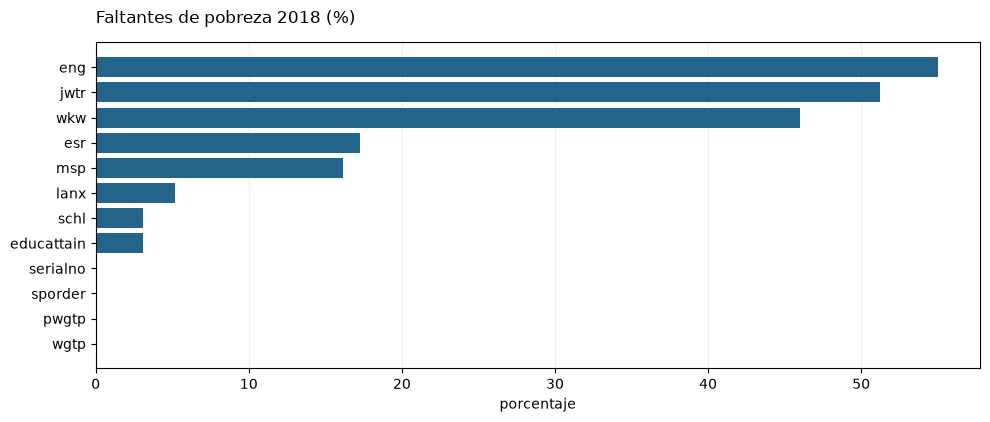

In [4]:
reporte = p.calidad(df_crudo)
p.tabla(reporte, 100)
p.guardar_json("03_calidad_pobreza.json", reporte)
p.barras(
    sorted(
        reporte,
        key=lambda r:r["faltantes"],reverse=True
    )[:12], 
    "columna", 
    "porcentaje",
    "Faltantes de pobreza 2018 (%)", 
    "calidad_pobreza.png"
)

## 4. Limpieza y conversión

Prepara los datos para poder convertir textos en números, identificar distritos y detectar valores que no funcionan para los cálculos.

- `SERIALNO`: identifica hogar
- `SPORDER`: identifica posición de la persona

In [5]:
# Revisar registros repetidos
unicos, auditoria = p.depurar_identificador(
    df_crudo, 
    ["serialno", "sporder"]
)

# Lista de nombres de columnas
numericas = [
    "pwgtp", 
    "agep", 
    "boro", 
    "educattain", 
    "nycgov_pov_stat", 
    "off_pov_stat",
    "nycgov_income", 
    "nycgov_threshold", 
    "est_povgap", 
    "est_povgapindex"
]

# Crear versión numérica
base = unicos
for c in numericas:
    base = base.withColumn(
        c + "_num",
        p.numero(c, espanol=True)
    )

print("Columnas numéricas creadas:",
    [c for c in base.columns if c.endswith("_num")]
)


# Revisar las conversiones
conversion = base.agg(*[
    F.sum(
        (
            p.texto(c).isNotNull()
            & F.col(c + "_num").isNull()
        ).cast("long")
    ).alias(c)
    for c in numericas
])

reporte_conversion = p.filas(conversion)

p.tabla(reporte_conversion)

ruta_conversion = p.guardar_json("03_conversion_numerica.json", reporte_conversion)
print("Reporte de conversión guardado en:", ruta_conversion)

base = (
    base # Anade columna de distrito traduciendo código a nombre y el año
        .withColumn(
            "borough", 
            p.mapa("boro", p.BORO_POBREZA)
        )
        .withColumn("anio", F.lit(ANIO))
)

# Contar filas con peso ausente, cero o negativo
auditoria["pesos_invalidos"] = base.filter(
    F.col("pwgtp_num").isNull() | (F.col("pwgtp_num") <= 0)
).count()

# Contar filas cuyo código no se puede traducir a distrito
auditoria["borough_desconocido"] = base.filter(
    F.col("borough").isNull()
).count()

# Establecer estados económico (Pobreza - No Pobreza)
auditoria["estado_pobreza_desconocido"] = base.filter(
    F.col("nycgov_pov_stat_num").isNull() | ~F.col("nycgov_pov_stat_num").isin(1,2) # ~ es negación
).count()

p.tabla([auditoria])
p.guardar_json("03_limpieza_pobreza.json", auditoria)

# Se construye tabla con pesos positivos
personas = base.filter(F.col("pwgtp_num") > 0).cache()

# Imprime tabla con número de conversiones fallidas para cada variable.

# Imprimir tabla con conversiones
base.select(
    "agep",
    "agep_num",
    "nycgov_income",
    "nycgov_income_num"
).show(10, truncate=False)

Columnas numéricas creadas: ['pwgtp_num', 'agep_num', 'boro_num', 'educattain_num', 'nycgov_pov_stat_num', 'off_pov_stat_num', 'nycgov_income_num', 'nycgov_threshold_num', 'est_povgap_num', 'est_povgapindex_num']


pwgtp,agep,boro,educattain,nycgov_pov_stat,off_pov_stat,nycgov_income,nycgov_threshold,est_povgap,est_povgapindex
0,0,0,0,0,0,0,0,0,0


Reporte de conversión guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/03_conversion_numerica.json


filas_originales,duplicados_exactos,filas_sin_clave,filas_con_clave_conflictiva_excluidas,filas_conservadas,pesos_invalidos,borough_desconocido,estado_pobreza_desconocido
68273,0,0,0,68273,0,0,0


+----+--------+-------------+-----------------+
|agep|agep_num|nycgov_income|nycgov_income_num|
+----+--------+-------------+-----------------+
|45  |45.0    |41.531,906   |41531.906        |
|48  |48.0    |90.503,313   |90503.313        |
|59  |59.0    |139.129,98   |139129.98        |
|56  |56.0    |18.893,045   |18893.045        |
|50  |50.0    |44.138,605   |44138.605        |
|33  |33.0    |36.981,574   |36981.574        |
|56  |56.0    |73.741,266   |73741.266        |
|45  |45.0    |29.944,441   |29944.441        |
|55  |55.0    |12.685,553   |12685.553        |
|30  |30.0    |62.901,41    |62901.41         |
+----+--------+-------------+-----------------+
only showing top 10 rows


## 5. Muestra y población representada

El conteo de filas y la suma de pesos son magnitudes distintas. Este bloque produce los siguientes indicadores con el objetivo de distinguir muestra y población:

- `personas_muestra_con_peso_valido`: Filas con peso válido
- `personas_representadas`: Suma de pesos
- `edad_minima`: Menor edad disponible
- `edad_maxima`: Mayor edad disponible

In [6]:
descripcion = personas.agg(
    F.count("*").alias("personas_muestra_con_peso_valido"),
    F.sum("pwgtp_num").alias("personas_representadas"),
    F.min("agep_num").alias("edad_minima"), 
    F.max("agep_num").alias("edad_maxima")
)

p.tabla(p.filas(descripcion))
ruta = p.guardar_json("muestra_poblacion.json", p.filas(descripcion))
print("Reporte guardado en: ", ruta)

personas_muestra_con_peso_valido,personas_representadas,edad_minima,edad_maxima
68273,8218313.0,0.0,95.0


Reporte guardado en:  /opt/cluster/Proyecto/Entrega_1/resultados/muestra_poblacion.json


## 6. Estructura por edad

En este apartado se genera una gráfica con la distribución de los datos por edades.

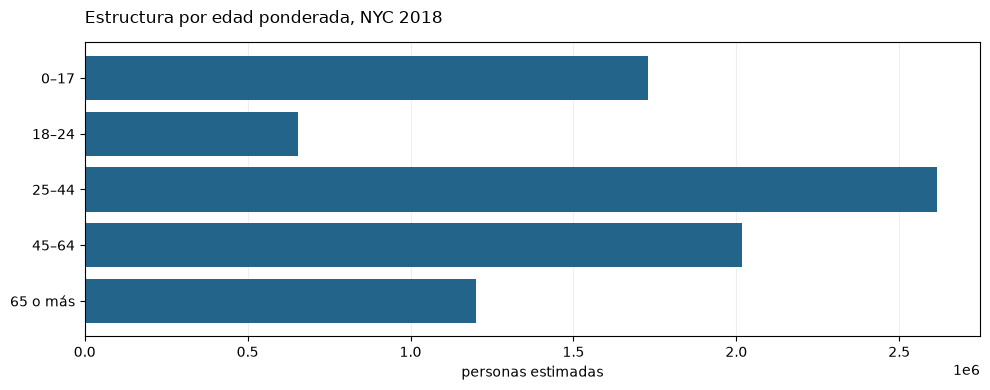

Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/edades.json


In [7]:
# Se segmentan los registros por grupos de edades por ponderación
edades = (
    personas
        .withColumn(
            "grupo_edad", 
            F.when(
                F.col("agep_num").isNull() | (F.col("agep_num") < 0), "Sin edad válida"
            )
            .when(F.col("agep_num") < 18, "0–17")
            .when(F.col("agep_num") < 25, "18–24")
            .when(F.col("agep_num") < 45, "25–44")
            .when(F.col("agep_num") < 65, "45–64")
            .otherwise("65 o más")
        )
        .groupBy("grupo_edad")
        .agg(
            F.sum("pwgtp_num").alias("personas_estimadas")
        ).orderBy("grupo_edad")
)

# Mostrar salidas de resultados de segmentación
datos = p.filas(edades)
p.barras(datos, "grupo_edad", "personas_estimadas", "Estructura por edad ponderada, NYC 2018", "edades.png")
ruta = p.guardar_json("edades.json", datos)
print("Reporte guardado en:", ruta)

## 7. Educación en población adulta

En este bloque se encuentra un estimado del nivel edicativo de las personas. Las cuatro categorías a discutir son:

- Menor a una educación secundaria
- Secundaria completada
- Estudio superior SIN título de pregrado
- Estudio superior CON título de pregrado o superior al pregrado

Para este apartado, se usan personas mayores a 25 años. Esto se hace debido a que, en Estados Unidos, la media de edad de graduación de un pregrado es entre 22 y 24 años. No se incluyen personas menores a 25 años ya que las condiciones bajo las cuales se evaluarán los límites educativos de las personas no aplican de igual manera a menores de edad y a mayores de edad.

Adultos sin categoría educativa válida: 0


educattain_num,personas_estimadas,nivel
1.0,989510.0,Menos de secundaria
2.0,1369308.0,Secundaria completa
3.0,1165451.0,Estudios superiores sin bachelor
4.0,2311592.0,Bachelor o superior


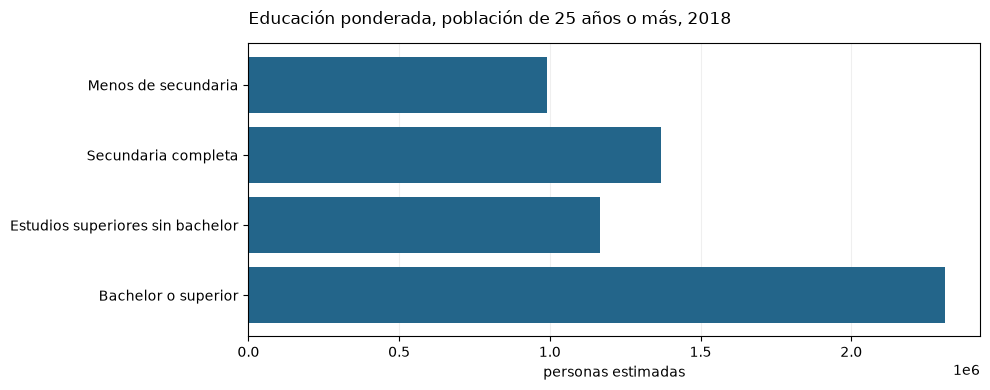

Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/educacion.json


In [11]:
# Filtro de edad
adultos = personas.filter(F.col("agep_num") >= 25)

# Número de registros que no cuentan con una categoría válida del nivel educativo
print("Adultos sin categoría educativa válida:", adultos.filter(F.col("educattain_num").isNull() | ~F.col("educattain_num").isin(1,2,3,4)).count())

# Se hace un mapeo del nivel educativo de las personas registradas (después de los filtros previos), y se agrupan por el nivel educativo
educacion = (adultos.filter(F.col("educattain_num").isin(1,2,3,4))
    .groupBy("educattain_num").agg(F.sum("pwgtp_num").alias("personas_estimadas"))
    .withColumn("nivel", p.mapa("educattain_num", p.EDUCACION)).orderBy("educattain_num"))

# Se genera una tabla de educación ponderada para visualizar resultados
datos = p.filas(educacion)
p.tabla(datos)
p.barras(datos,"nivel","personas_estimadas","Educación ponderada, población de 25 años o más, 2018","educacion.png")
ruta = p.guardar_json("educacion.json", datos)
print("Reporte guardado en:", ruta)

## 8. Estado de pobreza a escala de ciudad

En este bloque se obtiene el número de personas registradas, junto con un índice que indica si la persona está en condición de pobreza (1), o no (2). Los resultados se agrupan por condición. Al final, se obtiene el porcentaje total de habitantes de la ciudad que viven en pobreza.

In [12]:
# Se obtienen los registros cuyo indicador de pobreza sea válido
validos_pobreza = personas.filter(F.col("nycgov_pov_stat_num").isin(1,2))

# Se calcula el total de registros válidos disponibles. Se hace para toda la ciudad ya que no se aplica un filtro por borough
estado_ciudad = validos_pobreza.agg(
    F.sum("pwgtp_num").alias("denominador_personas"), # Se usa el peso de las personas para calcular el total de personas representadas
    F.sum(F.when(F.col("nycgov_pov_stat_num") == 1, F.col("pwgtp_num")).otherwise(0)).alias("personas_en_pobreza")
).withColumn("pobreza_pct", F.when(F.col("denominador_personas")>0, 100*F.col("personas_en_pobreza")/F.col("denominador_personas")))

# Se genera un reporte para visualizar los datos
p.tabla(p.filas(estado_ciudad))
ruta = p.guardar_json("pobreza_ciudad.json", p.filas(estado_ciudad))
print("Reporte guardado en:", ruta)

denominador_personas,personas_en_pobreza,pobreza_pct
8218313.0,1586893.0,19.309230495358353


Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/pobreza_ciudad.json


## 9. Preparación del perfil territorial

Se guardan tasas con sus numeradores y denominadores para que sean auditables. No se suman brechas monetarias repetidas entre miembros de una familia. Cinco distritos no bastan para inferir relaciones causales ni para un modelo predictivo territorial sólido.

In [16]:
# Se calcula la pobreza por año (solo aplica 2018) y por distrito
territorial = (
    validos_pobreza # Tiene peso poblacional positivo y clasifcación válida de pobreza
    .filter(F.col("borough").isNotNull()) # Se obtienen registros que tengan un distrito asociado
    .groupBy("anio", "borough")
    .agg(
        # Se cuenta la cantidad de filas y se obtiene la población representada
        F.count("*").alias("muestra_pobreza"),
        F.sum("pwgtp_num").alias("denominador_pobreza"),

        # El peso se suma si el indicador de pobreza es 1. Por el contrario, se suma un 0
        F.sum(
            F.when(
                F.col("nycgov_pov_stat_num") == 1,
                F.col("pwgtp_num")
            ).otherwise(0)
        ).alias("numerador_pobreza")
    )
)

# Se obtiene el porcentaje de pobreza del distrito
territorial = territorial.withColumn(
    "pobreza_pct",
    100 * F.col("numerador_pobreza") / F.col("denominador_pobreza")
)

# Se calcula el indicador de educación por año (solo aplica 2018) y por distrito
edu_territorial = (
    adultos # Tiene registros de edad válido
    .filter(
        F.col("borough").isNotNull() # Se obtienen registros que tengan un distrito asociado
        & F.col("educattain_num").isin(1, 2, 3, 4) # Se obtienen registros que tengan indicador educativo asociado
    )
    .groupBy("anio", "borough") # Se agrupa por año y por distrito
    .agg(
        # Población representada de 25 años o más
        F.sum("pwgtp_num").alias("denominador_educacion_25mas"),

        # Se suman los registros de las personas que no terminaron la secundaria
        F.sum(
            F.when(
                F.col("educattain_num") == 1,
                F.col("pwgtp_num")
            ).otherwise(0)
        ).alias("numerador_sin_secundaria")
    )
)

# Se calcula el porcentaje de adultos de 25 años o más sin secundaria completa
edu_territorial = edu_territorial.withColumn(
    "sin_secundaria_25mas_pct",
    100 * F.col("numerador_sin_secundaria")
        / F.col("denominador_educacion_25mas")
)

# Se unen resultados y tablas usando el mismo año y distrito
resumen = territorial.join(
    edu_territorial,
    ["anio", "borough"],
    "full"
)

# Se genera un reporte para visualizar los datos
ruta = p.exportar_resumen(
    resumen,
    "pobreza_resumen.json",
    "Pobreza_NY.csv",
    "disponible",
    {
        "anio_de_fuente": 2018,
        "auditoria": auditoria,
        "peso": "PWGTP",
        "universo_educacion": "25 años o más",
        "nota": (
            "Estimaciones puntuales, no se calcularon errores de muestreo ni intervalos de confianza"
        )
    }
)

p.tabla(p.filas(resumen.orderBy("anio", "borough")))
print("Reporte guardado en:", ruta)

anio,borough,muestra_pobreza,denominador_pobreza,numerador_pobreza,pobreza_pct,denominador_educacion_25mas,numerador_sin_secundaria,sin_secundaria_25mas_pct
2018,Bronx,9806,1389245.0,376487.0,27.100115530378012,902379.0,236946.0,26.257924885220067
2018,Brooklyn,24184,2540638.0,516035.0,20.31123678383146,1751207.0,287601.0,16.423015668621698
2018,Manhattan,9065,1568288.0,236151.0,15.057884776265585,1227516.0,143281.0,11.672434412260207
2018,Queens,21198,2250749.0,383134.0,17.02251117294732,1628155.0,281924.0,17.315550423639028
2018,Staten Island,4020,469393.0,75086.0,15.996403866269842,326604.0,39758.0,12.173151584181456


Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/pobreza_resumen.json


## Cierre

Los JSON y PNG quedan guardados.

In [17]:
# Cierra sesión y limpia cache

spark.catalog.clearCache()
spark.stop()